# Analisis Lengkap Dataset Pickle

Notebook ini menganalisis isi file pickle:

- Struktur data root
- Bentuk dan tipe `keypoints`
- Statistik jumlah frame
- Konsistensi shape/dtype
- Cek nilai nol (indikasi landmark hilang)
- Menampilkan isi array NumPy secara langsung

In [1]:
import pickle
import numpy as np
from pathlib import Path

pkl_path = Path("data/pickle/pose_data_isharah2000_hands_lips_body_phase2_SI.pkl")

with open(pkl_path, "rb") as f:
    obj = pickle.load(f)

print("File:", pkl_path)
print("ROOT TYPE:", type(obj))

File: data\pickle\pose_data_isharah2000_hands_lips_body_phase2_SI.pkl
ROOT TYPE: <class 'dict'>


## 1) Cek Struktur Dasar

Cell ini menampilkan:
- jumlah sampel
- beberapa key pertama
- field yang tersedia di dalam 1 sampel
- shape dan dtype dari array `keypoints`.

In [2]:
if not isinstance(obj, dict):
    raise TypeError(f"Objek root bukan dict, tapi {type(obj)}")

keys = list(obj.keys())
print("Jumlah key root:", len(keys))
print("5 key pertama:", keys[:5])

first_key = keys[0]
sample = obj[first_key]
print("\nSample key:", first_key)
print("Sample type:", type(sample))

if isinstance(sample, dict):
    print("Field sample:", list(sample.keys()))

kp = sample.get("keypoints") if isinstance(sample, dict) else None
if isinstance(kp, np.ndarray):
    print("keypoints type:", type(kp))
    print("keypoints shape:", kp.shape)
    print("keypoints dtype:", kp.dtype)
    print("keypoints min/max:", float(kp.min()), float(kp.max()))
else:
    print("Field 'keypoints' tidak ditemukan atau bukan np.ndarray")

Jumlah key root: 29250
5 key pertama: ['00_0001', '00_0002', '00_0003', '00_0004', '00_0005']

Sample key: 00_0001
Sample type: <class 'dict'>
Field sample: ['keypoints']
keypoints type: <class 'numpy.ndarray'>
keypoints shape: (55, 86, 2)
keypoints dtype: float64
keypoints min/max: 267.5226205587387 1261.8659591674805


## 2) Statistik Global Dataset

Cell ini menghitung statistik seluruh sampel:
- distribusi jumlah frame
- konsistensi shape `(T, 86, 2)`
- distribusi dtype
- nilai minimum/maksimum global.

In [3]:
frame_lengths = []
shape_counts = {}
dtype_counts = {}
invalid_samples = []

global_min = np.inf
global_max = -np.inf

for sid, item in obj.items():
    kp = item.get("keypoints") if isinstance(item, dict) else None

    if not isinstance(kp, np.ndarray):
        invalid_samples.append((sid, type(kp)))
        continue

    frame_lengths.append(kp.shape[0])

    shape_key = tuple(kp.shape[1:])
    shape_counts[shape_key] = shape_counts.get(shape_key, 0) + 1

    dtype_key = str(kp.dtype)
    dtype_counts[dtype_key] = dtype_counts.get(dtype_key, 0) + 1

    kmin = np.min(kp)
    kmax = np.max(kp)
    if kmin < global_min:
        global_min = kmin
    if kmax > global_max:
        global_max = kmax

frame_lengths = np.array(frame_lengths)

print("Total sampel:", len(obj))
print("Sampel valid ndarray:", len(frame_lengths))
print("Sampel invalid:", len(invalid_samples))

print("\nShape (dimensi ke-2 dan ke-3) terbanyak:")
for k, v in sorted(shape_counts.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  {k}: {v}")

print("\nDistribusi dtype:")
for k, v in sorted(dtype_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"  {k}: {v}")

print("\nStatistik jumlah frame per sampel:")
print("  min   :", int(frame_lengths.min()))
print("  p25   :", float(np.percentile(frame_lengths, 25)))
print("  median:", float(np.median(frame_lengths)))
print("  mean  :", float(frame_lengths.mean()))
print("  p75   :", float(np.percentile(frame_lengths, 75)))
print("  max   :", int(frame_lengths.max()))

print("\nRentang nilai koordinat global:")
print("  min:", float(global_min))
print("  max:", float(global_max))

if invalid_samples:
    print("\nContoh sampel invalid:", invalid_samples[:3])

Total sampel: 29250
Sampel valid ndarray: 29250
Sampel invalid: 0

Shape (dimensi ke-2 dan ke-3) terbanyak:
  (86, 2): 29250

Distribusi dtype:
  float64: 29250

Statistik jumlah frame per sampel:
  min   : 29
  p25   : 118.0
  median: 158.0
  mean  : 187.35692307692307
  p75   : 227.0
  max   : 843

Rentang nilai koordinat global:
  min: -957.3573017120361
  max: 5887.2528076171875


## 3) Cek Nilai Nol (Landmark Hilang)

Banyak pipeline mengisi titik yang tidak terdeteksi dengan nol.
Cell ini menghitung:
- berapa frame yang punya minimal 1 titik bernilai `[0, 0]`
- berapa banyak keypoint nol terhadap total keypoint.

In [4]:
total_frames = 0
total_keypoints = 0
zero_keypoints = 0
frames_with_any_zero = 0

for item in obj.values():
    kp = item.get("keypoints") if isinstance(item, dict) else None
    if not isinstance(kp, np.ndarray) or kp.ndim != 3 or kp.shape[2] != 2:
        continue

    # Mask keypoint bernilai [0, 0]
    zero_mask = np.all(kp == 0, axis=2)  # (T, 86)

    total_frames += kp.shape[0]
    total_keypoints += kp.shape[0] * kp.shape[1]
    zero_keypoints += int(zero_mask.sum())
    frames_with_any_zero += int(np.any(zero_mask, axis=1).sum())

print("Total frame:", total_frames)
print("Frame dengan minimal 1 keypoint nol:", frames_with_any_zero)
print("Persentase frame terdampak:", round(frames_with_any_zero / total_frames * 100, 4), "%")
print("Total keypoint:", total_keypoints)
print("Keypoint [0,0]:", zero_keypoints)
print("Persentase keypoint nol:", round(zero_keypoints / total_keypoints * 100, 4), "%")

Total frame: 5480190
Frame dengan minimal 1 keypoint nol: 1981326
Persentase frame terdampak: 36.1543 %
Total keypoint: 471296340
Keypoint [0,0]: 55548782
Persentase keypoint nol: 11.7864 %


## 4) Lihat Isi Array NumPy (Raw)

Cell ini menampilkan isi array secara langsung:
- shape sampel
- frame pertama lengkap `(86, 2)`
- potongan frame awal
- pemisahan region (left/right hand, mouth, pose).

In [5]:
# Pilih sampel yang ingin dilihat
sample_id = keys[0]
kp = obj[sample_id]["keypoints"]

np.set_printoptions(precision=3, suppress=True, linewidth=140)

print("Sample ID:", sample_id)
print("Shape:", kp.shape)
print("Dtype:", kp.dtype)

print("\nFrame pertama (lengkap 86x2):")
print(kp[0])

print("\n3 frame pertama, 10 keypoint pertama:")
print(kp[:3, :10, :])

# Region slicing sesuai layout 86 keypoints
left_hand = kp[:, 0:21, :]
right_hand = kp[:, 21:42, :]
mouth = kp[:, 42:61, :]
pose = kp[:, 61:86, :]

print("\nShape per region:")
print("Left hand :", left_hand.shape)
print("Right hand:", right_hand.shape)
print("Mouth     :", mouth.shape)
print("Pose      :", pose.shape)

print("\nFrame pertama - Left hand (5 titik pertama):")
print(left_hand[0, :5, :])

Sample ID: 00_0001
Shape: (55, 86, 2)
Dtype: float64

Frame pertama (lengkap 86x2):
[[ 825.663  813.146]
 [ 859.33   795.601]
 [ 901.359  795.821]
 [ 936.268  807.443]
 [ 963.586  813.128]
 [ 874.95   785.809]
 [ 905.23   800.643]
 [ 926.518  812.546]
 [ 945.581  821.681]
 [ 856.948  807.888]
 [ 896.334  838.553]
 [ 921.924  861.609]
 [ 941.372  880.229]
 [ 841.401  832.243]
 [ 880.299  861.003]
 [ 907.296  880.367]
 [ 928.862  894.078]
 [ 827.41   855.247]
 [ 860.676  880.704]
 [ 882.769  895.699]
 [ 902.149  907.451]
 [1085.149  888.575]
 [1063.186  856.001]
 [1027.23   840.307]
 [ 990.982  838.918]
 [ 966.297  821.682]
 [1040.9    870.908]
 [ 999.889  874.827]
 [ 971.209  878.98 ]
 [ 946.423  882.51 ]
 [1045.766  904.597]
 [ 996.203  922.414]
 [ 960.812  930.775]
 [ 933.733  934.607]
 [1046.908  929.494]
 [ 997.732  945.669]
 [ 963.564  949.327]
 [ 937.63   948.55 ]
 [1045.993  946.829]
 [1003.662  962.245]
 [ 975.92   964.969]
 [ 952.867  962.732]
 [ 926.219  322.283]
 [ 927.289  3

## 5) Visual Ringkas

Plot ini membantu melihat sebaran keypoint pada satu frame.
Sumbu `y` dibalik agar lebih mirip koordinat citra (origin di kiri-atas).

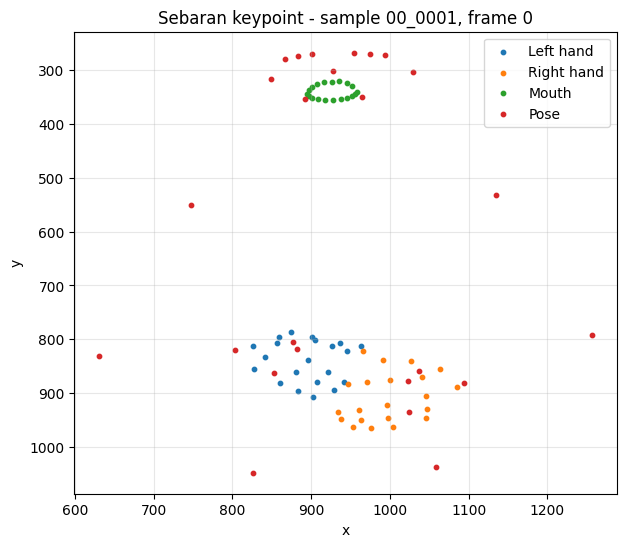

In [6]:
import matplotlib.pyplot as plt

frame_idx = 0
pts = kp[frame_idx]  # (86, 2)

plt.figure(figsize=(7, 6))
plt.scatter(pts[0:21, 0], pts[0:21, 1], s=10, label="Left hand")
plt.scatter(pts[21:42, 0], pts[21:42, 1], s=10, label="Right hand")
plt.scatter(pts[42:61, 0], pts[42:61, 1], s=10, label="Mouth")
plt.scatter(pts[61:86, 0], pts[61:86, 1], s=10, label="Pose")

plt.gca().invert_yaxis()
plt.title(f"Sebaran keypoint - sample {sample_id}, frame {frame_idx}")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()